In [32]:
from modeling.data.master import build_daily
from modeling.features import assemble_features
from modeling.metrics import mae, rmse, poisson_deviance
from modeling.models import build_model
from modeling.split import make_split
from modeling.evaluate import _load_run
import pickle
from types import SimpleNamespace
from omegaconf import DictConfig, OmegaConf

In [33]:
cfg = OmegaConf.create({'load_model': 'ward3_xgb_20200601_20251231_20260320_8e7638f5'})
model_path, run_cfg = _load_run(cfg)
with open(model_path, "rb") as f:
    saved = pickle.load(f)
model = saved["model"]
feature_cols = saved["feature_cols"]
feat_params = SimpleNamespace(**saved["feat_params"])

In [34]:
pothole_df, weather_df = build_daily(run_cfg)
feat_df = assemble_features(pothole_df, weather_df, feat_params)
feat_df = make_split(feat_df, run_cfg.split)


[assemble_features] kept 1819/1826 rows (99.6%) after dropping NaNs


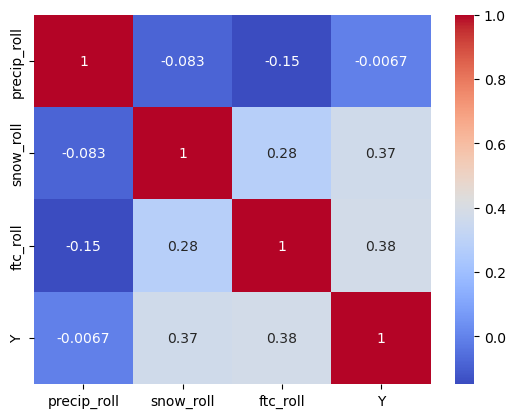

In [35]:
# get correlation matrix for precip, snow, ftc: 
import seaborn as sns
import matplotlib.pyplot as plt

# Create a correlation matrix
sns.heatmap(feat_df[['precip_roll', 'snow_roll', 'ftc_roll', 'Y']].corr(), annot=True, cmap='coolwarm')
plt.show()



In [36]:
test_df = feat_df[feat_df["split"] == "test"]
X_test = test_df[feature_cols]
y_test = test_df["Y"]

In [37]:
train_val_df = feat_df[feat_df["split"].isin(["train", "val"])] # get the train and val set
X_tv = train_val_df[feature_cols]
y_tv = train_val_df["Y"] # get the target for the train and val set

In [38]:
model.predict(X_test, recursive = True)

array([14.13041  , 14.084905 , 14.86835  , 14.046789 , 15.024413 ,
       15.197839 , 14.619239 , 14.248698 , 12.231757 , 12.408612 ,
       11.568393 , 11.053283 , 11.003705 ,  9.709811 ,  8.745304 ,
        9.605959 ,  9.988417 ,  9.589172 , 10.121712 ,  9.883889 ,
       10.533307 , 13.811881 , 13.960683 , 13.835423 , 13.832423 ,
       14.365069 , 14.443704 , 14.278819 , 13.613513 , 13.321427 ,
       12.935218 , 13.365945 , 13.422489 , 13.604189 , 12.036295 ,
       13.349939 ,  8.288801 ,  8.317398 ,  8.285351 ,  9.542889 ,
       13.669493 , 13.483334 , 11.954941 , 11.113518 , 10.586035 ,
       10.414267 , 10.529806 ,  9.596853 ,  8.281475 , 13.257698 ,
       12.388819 , 12.439974 , 12.669861 , 13.480328 , 13.545418 ,
       12.342392 , 12.284674 , 10.511436 , 11.513499 , 11.325355 ,
       12.888944 , 12.823794 , 13.017652 , 13.923707 , 13.52004  ,
       13.475146 , 12.455636 , 11.07867  ,  9.65216  ,  8.447665 ,
        8.159102 ,  7.894974 ,  7.366757 ,  8.070628 ,  7.7881

In [39]:
# predict on the test set: 
y_test_preds = model.predict(X_test, recursive = True)
# predict on the train and val set: 
y_train_preds = model.predict(X_tv, recursive = True)


In [40]:
# append trains and predicteds: 
import numpy as np
y_true = np.concatenate([y_tv.values, y_test.values], axis=0)
y_pred_full = np.concatenate([y_train_preds, y_test_preds], axis=0)


# plot the residuals: 


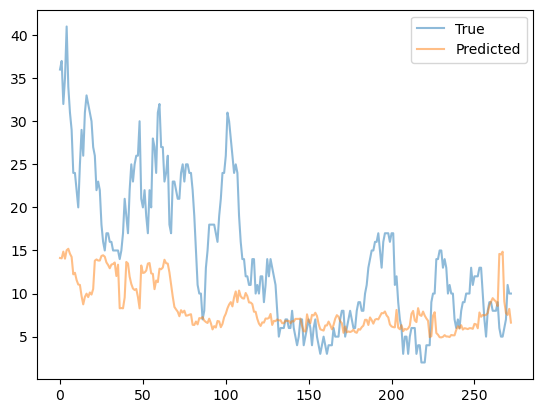

In [41]:
plt.plot(y_test.values, alpha=0.5, label='True')
plt.plot(y_test_preds, alpha=0.5, label='Predicted')
plt.legend()
plt.show()

In [44]:
model.seasonal_order

(0, 0, 1, 7)

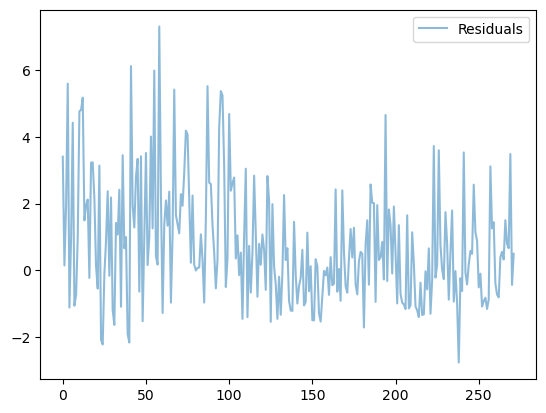

In [11]:
residuals = y_true - y_pred_full
plt.plot(residuals[-272:], alpha=0.5, label='Residuals')
plt.legend()
plt.show()


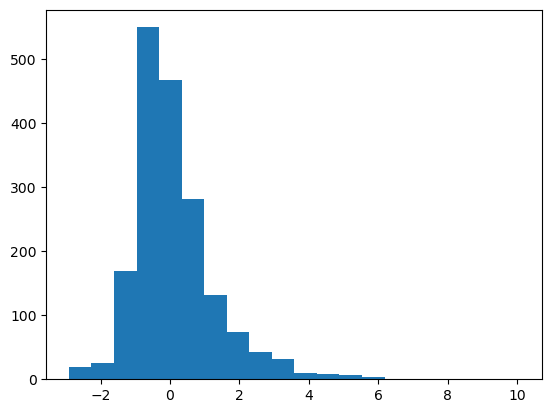

In [12]:
# distribution of residuals: 
z_residuals = (residuals - residuals.mean()) / residuals.std()
plt.hist(residuals, bins=20)
plt.show()
